In [1]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

PROJECT_ROOT = os.getcwd()

IMG_ROOT   = os.path.join(PROJECT_ROOT, "DeepJiandu")
LABEL_ROOT = os.path.join(PROJECT_ROOT, "DeepJiandu_labels")

for split in ["train", "val", "test"]:
    print(
        split,
        os.path.exists(os.path.join(IMG_ROOT, split)),
        os.path.exists(os.path.join(LABEL_ROOT, split))
    )


device = cuda
train True True
val True True
test True True


In [2]:
import os

LABEL_TRAIN_DIR = os.path.join(os.getcwd(), "DeepJiandu_labels", "train")

print("标签目录：", LABEL_TRAIN_DIR)
print("是否存在：", os.path.exists(LABEL_TRAIN_DIR))

files = os.listdir(LABEL_TRAIN_DIR)
print("文件总数：", len(files))
print("前 20 个文件名：")
for f in files[:20]:
    print("  ", f)


标签目录： D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\work1\prepare\DeepJiandu\DeepJiandu_labels\train
是否存在： True
文件总数： 5922
前 20 个文件名：
   1.xml
   10.xml
   1001.xml
   1002.xml
   1003.xml
   1004.xml
   1006.xml
   1007.xml
   1009.xml
   101.xml
   1011.xml
   1012.xml
   1014.xml
   1015.xml
   1016.xml
   1017.xml
   1019.xml
   1021.xml
   1022.xml
   1023.xml


In [4]:
import os

LABEL_TRAIN_DIR = os.path.join(
    os.getcwd(), "DeepJiandu_labels", "train"
)

xml_files = [f for f in os.listdir(LABEL_TRAIN_DIR) if f.endswith(".xml")]
print("XML 文件数：", len(xml_files))

# 只看第 1 个
xml_path = os.path.join(LABEL_TRAIN_DIR, xml_files[0])

with open(xml_path, "r", encoding="utf-8", errors="ignore") as f:
    content = f.read()

print("文件名：", xml_files[0])
print("原始 XML 内容：")
print("=" * 60)
print(content)
print("=" * 60)


XML 文件数： 5922
文件名： 1.xml
原始 XML 内容：
<annotation>
	<filename>1.bmp</filename>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>377</width>
		<height>996</height>
		<depth>1</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>&#38525;</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>225</xmin>
			<ymin>25</ymin>
			<xmax>328</xmax>
			<ymax>105</ymax>
		</bndbox>
	</object>
	<object>
		<name>&#21481;</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>222</xmin>
			<ymin>103</ymin>
			<xmax>320</xmax>
			<ymax>161</ymax>
		</bndbox>
	</object>
	<object>
		<name>&#38957;</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>227</xmin>
			<ymin>177</ymin>
			<xmax>332</xmax>
			<ymax>262</ymax>
		</bndbox>
	</object>
	<object>
		<name>&#22577;</name>
		<pose>Unspecified</pose>
		<truncated>0</tr

In [5]:
import xml.etree.ElementTree as ET

tree = ET.parse(xml_path)
root = tree.getroot()

def print_xml_tree(node, indent=0, max_depth=4):
    if indent > max_depth:
        return
    print("  " * indent + f"<{node.tag}>")
    for child in node:
        print_xml_tree(child, indent + 1, max_depth)

print("XML 结构树（前 4 层）：")
print_xml_tree(root)


XML 结构树（前 4 层）：
<annotation>
  <filename>
  <source>
    <database>
  <size>
    <width>
    <height>
    <depth>
  <segmented>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
      <ymin>
      <xmax>
      <ymax>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
      <ymin>
      <xmax>
      <ymax>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
      <ymin>
      <xmax>
      <ymax>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
      <ymin>
      <xmax>
      <ymax>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
      <ymin>
      <xmax>
      <ymax>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
      <ymin>
      <xmax>
      <ymax>
  <object>
    <name>
    <pose>
    <truncated>
    <difficult>
    <bndbox>
      <xmin>
 

In [6]:
names = root.findall(".//name")
print("发现的 <name> 标签数量：", len(names))
for n in names[:10]:
    print("name =", repr(n.text))


发现的 <name> 标签数量： 26
name = '陽'
name = '叩'
name = '頭'
name = '報'
name = '會'
name = '板'
name = '十'
name = '七'
name = '紺'
name = '足'


In [7]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

LABEL_TRAIN_DIR = os.path.join(os.getcwd(), "DeepJiandu_labels", "train")

def build_class_map_from_xml(label_dir):
    chars = []
    for fname in os.listdir(label_dir):
        if not fname.endswith(".xml"):
            continue
        xml_path = os.path.join(label_dir, fname)
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall("object"):
            name = obj.find("name").text.strip()
            chars.append(name)
    counter = Counter(chars)
    classes = sorted(counter.keys())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    return class_to_idx, counter

class_to_idx, char_freq = build_class_map_from_xml(LABEL_TRAIN_DIR)

print("类别数 =", len(class_to_idx))
print("前 20 个字符示例 =", list(class_to_idx.items())[:20])


类别数 = 2107
前 20 个字符示例 = [('□', 0), ('ム', 1), ('㒇', 2), ('㒼', 3), ('㞷', 4), ('㡒', 5), ('㢮', 6), ('㯼', 7), ('㷅', 8), ('㹆', 9), ('䅃', 10), ('䅣', 11), ('䅭', 12), ('䊮', 13), ('䊼', 14), ('䊽', 15), ('䌛', 16), ('䌳', 17), ('䏢', 18), ('䖟', 19)]


In [8]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CharCropDataset(Dataset):
    def __init__(self, img_dir, label_dir, class_to_idx, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = class_to_idx

        for xml_name in os.listdir(label_dir):
            if not xml_name.endswith(".xml"):
                continue

            xml_path = os.path.join(label_dir, xml_name)
            tree = ET.parse(xml_path)
            root = tree.getroot()

            img_name = root.find("filename").text
            img_path = os.path.join(img_dir, img_name)
            if not os.path.exists(img_path):
                continue

            for obj in root.findall("object"):
                name = obj.find("name").text.strip()
                bbox = obj.find("bndbox")

                xmin = int(bbox.find("xmin").text)
                ymin = int(bbox.find("ymin").text)
                xmax = int(bbox.find("xmax").text)
                ymax = int(bbox.find("ymax").text)

                self.samples.append(
                    (img_path, (xmin, ymin, xmax, ymax), self.class_to_idx[name])
                )

        assert len(self.samples) > 0, "没有生成任何单字样本"

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, (xmin, ymin, xmax, ymax), label = self.samples[idx]

        img = Image.open(img_path).convert("L")
        char_img = img.crop((xmin, ymin, xmax, ymax))

        if self.transform:
            char_img = self.transform(char_img)

        return char_img, label


In [9]:
from torchvision import transforms

train_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


In [10]:
from torch.utils.data import DataLoader

IMG_ROOT = os.path.join(os.getcwd(), "DeepJiandu")

train_ds = CharCropDataset(
    os.path.join(IMG_ROOT, "train"),
    os.path.join(LABEL_TRAIN_DIR),
    class_to_idx,
    transform=train_tfms
)

print("训练样本总数 =", len(train_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    num_workers=2
)


训练样本总数 = 79497


In [11]:
### 训练轮次设置

import os
import inspect
import xml.etree.ElementTree as ET
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ========== 训练配置（只改这里即可切换） ==========
# 1) 训练模式：默认 smoke（快速跑通）
#    - smoke: 小 batch + 限制 max_*_batches + 只跑 1 epoch（用于快速验证 forward/backward/保存/导出）
#    - full : 正常训练（跑全量，不限制 batch 数）
TRAIN_MODE = "full"  # smoke / full

# 2) 模型选择：三种模型一行切换
#    - resnet18 (baseline / 最稳的 smoke test)
#    - convnext_tiny
#    - mobilenet_v3_large
MODEL_NAME = "resnet18"  # resnet18 / convnext_tiny / mobilenet_v3_large

TRAIN_CFGS = {
    "smoke": {
        "batch_size": 4,
        "epochs": 1,
        "max_train_batches": 20,
        "max_val_batches": 10,
        "max_test_batches": 10,
    },
    "full": {
        "batch_size": 64,
        "epochs": 10,
        "max_train_batches": None,
        "max_val_batches": None,
        "max_test_batches": None,
    },
}

if TRAIN_MODE not in TRAIN_CFGS:
    raise ValueError(f"TRAIN_MODE must be one of {list(TRAIN_CFGS.keys())}, got {TRAIN_MODE!r}")

train_cfg = TRAIN_CFGS[TRAIN_MODE]
print("TRAIN_MODE =", TRAIN_MODE)
print("MODEL_NAME =", MODEL_NAME)
print("train_cfg =", train_cfg)

_need_patch = True
try:
    _sig = inspect.signature(CharCropDataset.__init__)
    _need_patch = ("skip_unknown" not in _sig.parameters)
except Exception:
    _need_patch = True

if _need_patch:
    class CharCropDataset(Dataset):
        def __init__(self, img_dir, label_dir, class_to_idx, transform=None, skip_unknown=True):
            self.samples = []
            self.transform = transform
            self.class_to_idx = class_to_idx
            self.skip_unknown = skip_unknown

            for xml_name in os.listdir(label_dir):
                if not xml_name.endswith(".xml"):
                    continue

                xml_path = os.path.join(label_dir, xml_name)
                tree = ET.parse(xml_path)
                root = tree.getroot()

                img_name = root.find("filename").text
                img_path = os.path.join(img_dir, img_name)
                if not os.path.exists(img_path):
                    continue

                for obj in root.findall("object"):
                    name = obj.find("name").text.strip()
                    if name not in self.class_to_idx:
                        if self.skip_unknown:
                            continue
                        raise KeyError(f"unknown class: {name}")

                    bbox = obj.find("bndbox")

                    xmin = int(bbox.find("xmin").text)
                    ymin = int(bbox.find("ymin").text)
                    xmax = int(bbox.find("xmax").text)
                    ymax = int(bbox.find("ymax").text)

                    self.samples.append(
                        (img_path, (xmin, ymin, xmax, ymax), self.class_to_idx[name])
                    )

            assert len(self.samples) > 0, "没有生成任何单字样本"

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            img_path, (xmin, ymin, xmax, ymax), label = self.samples[idx]

            img = Image.open(img_path).convert("L")
            char_img = img.crop((xmin, ymin, xmax, ymax))

            if self.transform:
                char_img = self.transform(char_img)

            return char_img, label

IMG_ROOT = os.path.join(os.getcwd(), "DeepJiandu")
LABEL_ROOT = os.path.join(os.getcwd(), "DeepJiandu_labels")

train_img_dir = os.path.join(IMG_ROOT, "train")
val_img_dir   = os.path.join(IMG_ROOT, "val")
test_img_dir  = os.path.join(IMG_ROOT, "test")

train_label_dir = os.path.join(LABEL_ROOT, "train")
val_label_dir   = os.path.join(LABEL_ROOT, "val")
test_label_dir  = os.path.join(LABEL_ROOT, "test")

train_ds = CharCropDataset(train_img_dir, train_label_dir, class_to_idx, transform=train_tfms, skip_unknown=True)
val_ds   = CharCropDataset(val_img_dir,   val_label_dir,   class_to_idx, transform=val_tfms,   skip_unknown=True)
test_ds  = CharCropDataset(test_img_dir,  test_label_dir,  class_to_idx, transform=val_tfms,   skip_unknown=True)

print("train samples =", len(train_ds))
print("val samples   =", len(val_ds))
print("test samples  =", len(test_ds))

batch_size = train_cfg["batch_size"]

num_workers = 0 if os.name == "nt" else 2
pin_memory = (device.type == "cuda")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

TRAIN_MODE = full
MODEL_NAME = resnet18
train_cfg = {'batch_size': 64, 'epochs': 10, 'max_train_batches': None, 'max_val_batches': None, 'max_test_batches': None}
train samples = 79497
val samples   = 10351
test samples  = 9854


In [12]:
import os
import json
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

num_classes = len(class_to_idx)

epochs = train_cfg["epochs"]


def _replace_conv_in_channels_to_1(conv: nn.Conv2d) -> nn.Conv2d:
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=conv.out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=conv.groups,
        bias=(conv.bias is not None),
        padding_mode=conv.padding_mode,
    )

    with torch.no_grad():
        if conv.weight.shape[1] == 3:
            new_conv.weight.copy_(conv.weight.mean(dim=1, keepdim=True))
        elif conv.weight.shape[1] == 1:
            new_conv.weight.copy_(conv.weight)
        else:
            raise ValueError(f"Unexpected conv.in_channels={conv.weight.shape[1]}")

        if conv.bias is not None:
            new_conv.bias.copy_(conv.bias)

    return new_conv


def build_model(model_name: str, num_classes: int):
    model_name = model_name.lower().strip()

    if model_name == "resnet18":
        try:
            weights = models.ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
        except Exception:
            model = models.resnet18(pretrained=True)

        model.conv1 = _replace_conv_in_channels_to_1(model.conv1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if model_name == "convnext_tiny":
        try:
            weights = models.ConvNeXt_Tiny_Weights.DEFAULT
            model = models.convnext_tiny(weights=weights)
        except Exception:
            model = models.convnext_tiny(pretrained=True)

        model.features[0][0] = _replace_conv_in_channels_to_1(model.features[0][0])
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model

    if model_name == "mobilenet_v3_large":
        try:
            weights = models.MobileNet_V3_Large_Weights.DEFAULT
            model = models.mobilenet_v3_large(weights=weights)
        except Exception:
            model = models.mobilenet_v3_large(pretrained=True)

        model.features[0][0] = _replace_conv_in_channels_to_1(model.features[0][0])
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model

    raise ValueError(f"Unknown model_name={model_name!r}. Use resnet18 / convnext_tiny / mobilenet_v3_large")


model = build_model(MODEL_NAME, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

amp_enabled = (device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

def _autocast_ctx():
    if amp_enabled:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    from contextlib import nullcontext
    return nullcontext()

save_path = os.path.join(os.getcwd(), f"char_{MODEL_NAME}_best_{TRAIN_MODE}.pth")
map_path = os.path.join(os.getcwd(), "class_to_idx.json")
best_val_top1 = 0.0

In [13]:
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

import torch

def _accuracy_topk(logits, targets, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        _, pred = logits.topk(maxk, dim=1, largest=True, sorted=True)
        pred = pred.t()  # [maxk, B]
        correct = pred.eq(targets.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0)
            res.append((correct_k / targets.size(0)).item())
        return res

def _accumulate_prf_counts(tp, fp, fn, pred, y, num_classes):
    pred = pred.view(-1)
    y = y.view(-1)

    correct = (pred == y)
    if correct.any():
        tp += torch.bincount(y[correct], minlength=num_classes)

    wrong = ~correct
    if wrong.any():
        fp += torch.bincount(pred[wrong], minlength=num_classes)
        fn += torch.bincount(y[wrong], minlength=num_classes)

@torch.no_grad()
def _compute_prf(tp, fp, fn):
    tp = tp.float()
    fp = fp.float()
    fn = fn.float()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    support = tp + fn

    valid_macro = (support > 0) | ((tp + fp) > 0)
    if valid_macro.any():
        macro_precision = precision[valid_macro].mean().item()
        macro_recall = recall[valid_macro].mean().item()
        macro_f1 = f1[valid_macro].mean().item()
    else:
        macro_precision = 0.0
        macro_recall = 0.0
        macro_f1 = 0.0

    total_support = support.sum().item()
    if total_support > 0:
        weighted_precision = (precision * support).sum().item() / total_support
        weighted_recall = (recall * support).sum().item() / total_support
        weighted_f1 = (f1 * support).sum().item() / total_support
    else:
        weighted_precision = 0.0
        weighted_recall = 0.0
        weighted_f1 = 0.0

    return {
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    }

@torch.no_grad()
def evaluate(model, loader, desc="val", max_batches=None):
    model.eval()
    total_loss = 0.0
    total_top1 = 0.0
    total_top5 = 0.0
    total_n = 0

    tp = torch.zeros(num_classes, dtype=torch.long)
    fp = torch.zeros(num_classes, dtype=torch.long)
    fn = torch.zeros(num_classes, dtype=torch.long)

    pbar = tqdm(loader, desc=desc, leave=False)
    for i, (x, y) in enumerate(pbar):
        if (max_batches is not None) and (i >= max_batches):
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with _autocast_ctx():
            logits = model(x)
            loss = criterion(logits, y)

        bsz = y.size(0)
        top1, top5 = _accuracy_topk(logits, y, topk=(1, 5))

        total_loss += loss.item() * bsz
        total_top1 += top1 * bsz
        total_top5 += top5 * bsz
        total_n += bsz

        pred = logits.argmax(dim=1)
        _accumulate_prf_counts(tp, fp, fn, pred.detach().cpu(), y.detach().cpu(), num_classes)

        pbar.set_postfix({
            "loss": f"{(total_loss / max(total_n, 1)):.4f}",
            "top1": f"{(total_top1 / max(total_n, 1)):.4f}",
            "top5": f"{(total_top5 / max(total_n, 1)):.4f}",
        })

    prf = _compute_prf(tp, fp, fn)

    return {
        "loss": total_loss / max(total_n, 1),
        "top1": total_top1 / max(total_n, 1),
        "top5": total_top5 / max(total_n, 1),
        **prf,
    }

def train_one_epoch(model, loader, desc="train", max_batches=None):
    model.train()
    total_loss = 0.0
    total_top1 = 0.0
    total_top5 = 0.0
    total_n = 0

    tp = torch.zeros(num_classes, dtype=torch.long)
    fp = torch.zeros(num_classes, dtype=torch.long)
    fn = torch.zeros(num_classes, dtype=torch.long)

    pbar = tqdm(loader, desc=desc, leave=False)
    for i, (x, y) in enumerate(pbar):
        if (max_batches is not None) and (i >= max_batches):
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with _autocast_ctx():
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bsz = y.size(0)
        top1, top5 = _accuracy_topk(logits, y, topk=(1, 5))

        total_loss += loss.item() * bsz
        total_top1 += top1 * bsz
        total_top5 += top5 * bsz
        total_n += bsz

        pred = logits.argmax(dim=1)
        _accumulate_prf_counts(tp, fp, fn, pred.detach().cpu(), y.detach().cpu(), num_classes)

        pbar.set_postfix({
            "loss": f"{(total_loss / max(total_n, 1)):.4f}",
            "top1": f"{(total_top1 / max(total_n, 1)):.4f}",
            "top5": f"{(total_top5 / max(total_n, 1)):.4f}",
        })

    prf = _compute_prf(tp, fp, fn)

    return {
        "loss": total_loss / max(total_n, 1),
        "top1": total_top1 / max(total_n, 1),
        "top5": total_top5 / max(total_n, 1),
        **prf,
    }

In [14]:
start_time = time.time()

history = {
    "epoch": [],
    "lr": [],
    "train_loss": [],
    "train_top1": [],
    "train_top5": [],
    "train_macro_precision": [],
    "train_macro_recall": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_top1": [],
    "val_top5": [],
    "val_macro_precision": [],
    "val_macro_recall": [],
    "val_macro_f1": [],
}

epoch_bar = tqdm(range(1, epochs + 1), desc="epochs", leave=True)
for epoch in epoch_bar:
    t0 = time.time()

    train_metrics = train_one_epoch(
        model,
        train_loader,
        desc=f"train e{epoch}",
        max_batches=train_cfg["max_train_batches"],
    )
    val_metrics = evaluate(
        model,
        val_loader,
        desc=f"val e{epoch}",
        max_batches=train_cfg["max_val_batches"],
    )

    scheduler.step()

    dt = time.time() - t0
    lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["lr"].append(lr)
    history["train_loss"].append(train_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["train_top5"].append(train_metrics["top5"])
    history["train_macro_precision"].append(train_metrics["macro_precision"])
    history["train_macro_recall"].append(train_metrics["macro_recall"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_top1"].append(val_metrics["top1"])
    history["val_top5"].append(val_metrics["top5"])
    history["val_macro_precision"].append(val_metrics["macro_precision"])
    history["val_macro_recall"].append(val_metrics["macro_recall"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    epoch_bar.set_postfix({
        "lr": f"{lr:.2e}",
        "train_top1": f"{train_metrics['top1']:.4f}",
        "val_top1": f"{val_metrics['top1']:.4f}",
        "val_f1": f"{val_metrics['macro_f1']:.4f}",
        "time_s": f"{dt:.1f}",
    })

    print(
        f"epoch {epoch:02d}/{epochs} | "
        f"lr={lr:.2e} | "
        f"train loss={train_metrics['loss']:.4f} top1={train_metrics['top1']:.4f} top5={train_metrics['top5']:.4f} "
        f"macro_p={train_metrics['macro_precision']:.4f} macro_r={train_metrics['macro_recall']:.4f} macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val loss={val_metrics['loss']:.4f} top1={val_metrics['top1']:.4f} top5={val_metrics['top5']:.4f} "
        f"macro_p={val_metrics['macro_precision']:.4f} macro_r={val_metrics['macro_recall']:.4f} macro_f1={val_metrics['macro_f1']:.4f} | "
        f"time={dt:.1f}s"
    )

    if val_metrics["top1"] > best_val_top1:
        best_val_top1 = val_metrics["top1"]

        torch.save(
            {
                "model": model.state_dict(),
                "epoch": epoch,
                "best_val_top1": best_val_top1,
                "num_classes": num_classes,
            },
            save_path,
        )

        with open(map_path, "w", encoding="utf-8") as f:
            json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

        print(f"saved best: top1={best_val_top1:.4f} -> {save_path}")

print("total training time (min) =", (time.time() - start_time) / 60.0)
print("best_val_top1 =", best_val_top1)


## 测试导出模型

epochs:   0%|          | 0/10 [00:00<?, ?it/s]

train e1:   0%|          | 0/1243 [00:00<?, ?it/s]

val e1:   0%|          | 0/162 [00:00<?, ?it/s]

epoch 01/10 | lr=2.93e-04 | train loss=3.5482 top1=0.3981 top5=0.5779 macro_p=0.0964 macro_r=0.0498 macro_f1=0.0564 | val loss=2.3960 top1=0.5285 top5=0.7352 macro_p=0.2323 macro_r=0.2006 macro_f1=0.1908 | time=590.1s
saved best: top1=0.5285 -> D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\work1\prepare\DeepJiandu\char_resnet18_best_full.pth


train e2:   0%|          | 0/1243 [00:00<?, ?it/s]

...

val e9:   0%|          | 0/162 [00:00<?, ?it/s]

epoch 09/10 | lr=7.34e-06 | train loss=0.2400 top1=0.9472 top5=0.9924 macro_p=0.9741 macro_r=0.9512 macro_f1=0.9602 | val loss=1.6392 top1=0.6935 top5=0.8477 macro_p=0.5053 macro_r=0.4703 macro_f1=0.4676 | time=591.3s
saved best: top1=0.6935 -> D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\work1\prepare\DeepJiandu\char_resnet18_best_full.pth


train e10:   0%|          | 0/1243 [00:00<?, ?it/s]

val e10:   0%|          | 0/162 [00:00<?, ?it/s]

epoch 10/10 | lr=0.00e+00 | train loss=0.1948 top1=0.9597 top5=0.9954 macro_p=0.9818 macro_r=0.9632 macro_f1=0.9707 | val loss=1.6400 top1=0.6942 top5=0.8492 macro_p=0.5094 macro_r=0.4758 macro_f1=0.4720 | time=578.7s
saved best: top1=0.6942 -> D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\work1\prepare\DeepJiandu\char_resnet18_best_full.pth
total training time (min) = 129.1595507224401
best_val_top1 = 0.694232441154543


In [15]:
import os
import io
import json
import warnings
import torch
import copy

# -----------------------------
# 前置检查
# -----------------------------
if "model" not in globals():
    raise RuntimeError("没有找到 model，请先运行模型构建与训练相关的 cell")

# -----------------------------
# 设置导出目录（FastAPI 用）
# -----------------------------
export_dir = r"D:\\project\\test\\model"
os.makedirs(export_dir, exist_ok=True)
print("✅ export_dir ->", export_dir)

# -----------------------------
# 确保 class_to_idx / num_classes / build_model 可用
# -----------------------------
if "class_to_idx" not in globals() or not isinstance(class_to_idx, dict) or len(class_to_idx) == 0:
    raise RuntimeError("class_to_idx 缺失或为空，请先运行生成 class_to_idx 的 cell")

if "num_classes" not in globals() or int(num_classes) <= 0:
    num_classes = len(class_to_idx)
num_classes = int(num_classes)

if "build_model" not in globals():
    raise RuntimeError("build_model 不存在，请先运行模型构建 cell")

# -----------------------------
# 保存 checkpoint（可选：确保 save_path / map_path 存在时可以落盘）
# -----------------------------
if "save_path" in globals() and isinstance(save_path, str):
    if not os.path.exists(save_path):
        torch.save(
            {
                "model": model.state_dict(),
                "epoch": int(history["epoch"][-1]) if ("history" in globals() and len(history.get("epoch", [])) > 0) else 0,
                "best_val_top1": float(best_val_top1) if "best_val_top1" in globals() else 0.0,
                "num_classes": int(num_classes),
                "model_name": MODEL_NAME,
            },
            save_path,
        )

# class_to_idx 统一写到 export_dir（FastAPI 用这里的文件）
classmap_path = os.path.join(export_dir, "class_to_idx.json")
with open(classmap_path, "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

# -----------------------------
# 加载 checkpoint -> CPU model（严格加载，确保完全初始化）
# -----------------------------
state_dict = None
if "save_path" in globals() and isinstance(save_path, str) and os.path.exists(save_path):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=FutureWarning)
        try:
            ckpt = torch.load(save_path, map_location="cpu", weights_only=True)
        except TypeError:
            ckpt = torch.load(save_path, map_location="cpu")
    state_dict = ckpt.get("model", ckpt)
else:
    state_dict = model.to("cpu").state_dict()

model_cpu = build_model(MODEL_NAME, num_classes).to("cpu")
model_cpu.load_state_dict(state_dict, strict=True)
model_cpu.eval()

# forward 必须返回 Tensor（不能是 None）
example_input = torch.randn(1, 1, 128, 128)
with torch.no_grad():
    _out = model_cpu(example_input)
if _out is None:
    raise RuntimeError("forward() 返回了 None，TorchScript 导出/加载将失败")

# -----------------------------
# 辅助：保存并验证 torch.jit.load
# -----------------------------
def _save_and_verify(jit_module, out_path, example):
    try:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        jit_module.save(out_path)
        m = torch.jit.load(out_path, map_location="cpu")
        m.eval()
        with torch.no_grad():
            y = m(example)
        if y is None:
            raise RuntimeError("loaded module forward() returned None")
        return out_path, None
    except Exception as e:
        return None, e

# -----------------------------
# 1) trace_raw（必出 & 必须可 load，FastAPI 默认用它）
# -----------------------------
trace_raw_file = f"char_{MODEL_NAME}_{TRAIN_MODE}_trace_raw.pt"
trace_raw_path = os.path.join(export_dir, trace_raw_file)

with torch.no_grad():
    traced_raw = torch.jit.trace(model_cpu, example_input, strict=False)

trace_raw_path_ok, err = _save_and_verify(traced_raw, trace_raw_path, example_input)
if err is not None:
    raise RuntimeError(f"trace_raw 保存/加载验证失败: {repr(err)}")
print("✅ exported trace_raw ->", trace_raw_path_ok)

# -----------------------------
# 2) trace_opt（尝试：freeze + optimize_for_inference；失败则跳过）
#    注意：你当前环境下 optimize 版本可能 load 报 value undefined，所以必须做验证
# -----------------------------
trace_final_file = trace_raw_file
trace_final_path = trace_raw_path_ok

trace_opt_file = f"char_{MODEL_NAME}_{TRAIN_MODE}_torchscript.pt"
trace_opt_path = os.path.join(export_dir, trace_opt_file)

try:
    # 尽量减少 mkldnn 相关的图变换（更稳）
    try:
        torch.backends.mkldnn.enabled = False
    except Exception:
        pass

    opt = traced_raw
    try:
        opt = torch.jit.freeze(opt)
    except Exception:
        pass

    opt = torch.jit.optimize_for_inference(opt)
    trace_opt_path_ok, opt_err = _save_and_verify(opt, trace_opt_path, example_input)

    if opt_err is None:
        trace_final_file = trace_opt_file
        trace_final_path = trace_opt_path_ok
        print("✅ exported trace_opt ->", trace_opt_path_ok)
    else:
        print("⚠️ trace_opt 不可用，回退 trace_raw。原因:", repr(opt_err))
except Exception as e:
    print("⚠️ trace_opt 导出异常，回退 trace_raw。原因:", repr(e))

# -----------------------------
# 3) script_raw（可选：能导出就导出；失败不阻断）
# -----------------------------
script_file = f"char_{MODEL_NAME}_{TRAIN_MODE}_script_raw.pt"
script_path = os.path.join(export_dir, script_file)
script_ok = None

try:
    scripted = torch.jit.script(model_cpu)
    script_ok, script_err = _save_and_verify(scripted, script_path, example_input)
    if script_err is None:
        print("✅ exported script_raw ->", script_ok)
    else:
        script_ok = None
        print("⚠️ script_raw 不可用（保存/加载验证失败）:", repr(script_err))
except Exception as e:
    script_ok = None
    print("⚠️ torch.jit.script export failed (non-fatal):", repr(e))

# -----------------------------
# meta.json（保证 trace_model_file 指向最终可 load 的文件）
# -----------------------------
meta = {
    "train_mode": TRAIN_MODE,
    "model_name": MODEL_NAME,
    "num_classes": int(num_classes),
    "input": {
        "shape": [1, 1, 128, 128],
        "color": "L",
        "normalize_mean": [0.5],
        "normalize_std": [0.5],
    },
    "trace_model_file": trace_final_file,
    "script_model_file": os.path.basename(script_ok) if script_ok else None,
    "class_to_idx_file": os.path.basename(classmap_path),
}

meta_path = os.path.join(export_dir, f"char_{MODEL_NAME}_{TRAIN_MODE}_meta.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✅ exported meta ->", meta_path)
print("✅ FastAPI 应加载 ->", os.path.join(export_dir, trace_final_file))


✅ export_dir -> D:\\project\\test\\model
✅ exported trace_raw -> D:\\project\\test\\model\char_resnet18_full_trace_raw.pt
⚠️ trace_opt 不可用，回退 trace_raw。原因: RuntimeError("required keyword attribute 'value' is undefined")
✅ exported script_raw -> D:\\project\\test\\model\char_resnet18_full_script_raw.pt
✅ exported meta -> D:\\project\\test\\model\char_resnet18_full_meta.json
✅ FastAPI 应加载 -> D:\\project\\test\\model\char_resnet18_full_trace_raw.pt



=== 训练/验证指标汇总 ===
epoch	lr	train_loss	train_top1	train_macro_precision	train_macro_recall	train_macro_f1	val_loss	val_top1	val_macro_precision	val_macro_recall	val_macro_f1
1	0.000293	3.548227	0.398141	0.096362	0.049787	0.056398	2.396046	0.528451	0.232331	0.200562	0.190810
2	0.000271	2.026498	0.591796	0.201565	0.148695	0.161382	1.842547	0.615399	0.374093	0.327342	0.324785
3	0.000238	1.525666	0.666805	0.310977	0.241800	0.262145	1.700639	0.646025	0.447922	0.391721	0.391009
4	0.000196	1.205807	0.721348	0.435234	0.349904	0.376401	1.591662	0.673268	0.474062	0.427662	0.424433
5	0.000150	0.937781	0.775740	0.596417	0.509742	0.538352	1.567711	0.679355	0.490324	0.443355	0.442236
6	0.000104	0.694072	0.830547	0.790245	0.711552	0.738478	1.582287	0.684088	0.486453	0.450929	0.445896
7	0.000062	0.491774	0.881417	0.904531	0.849524	0.869464	1.594444	0.690851	0.488071	0.462269	0.452634
8	0.000029	0.334152	0.921557	0.952799	0.913256	0.928150	1.628446	0.690948	0.499118	0.465823	0.461503
9	0.000007	0.24000

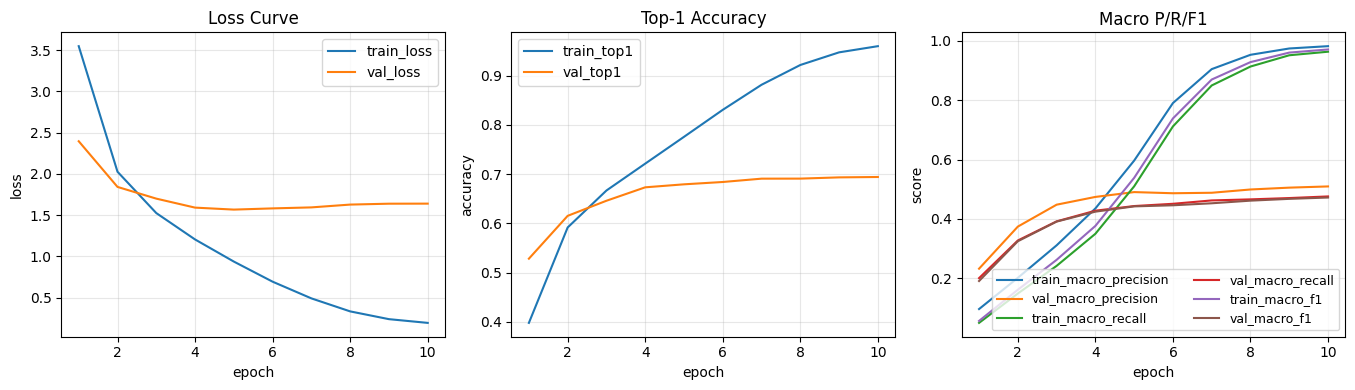

In [16]:
import os
import csv

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib 不可用，跳过绘图：", repr(e))

if "history" not in globals():
    raise RuntimeError("没有找到 history，请先运行训练 cell（cell 12）")

print("\n=== 训练/验证指标汇总 ===")
header = [
    "epoch",
    "lr",
    "train_loss",
    "train_top1",
    "train_macro_precision",
    "train_macro_recall",
    "train_macro_f1",
    "val_loss",
    "val_top1",
    "val_macro_precision",
    "val_macro_recall",
    "val_macro_f1",
]
print("\t".join(header))
for i in range(len(history["epoch"])):
    row = [
        history["epoch"][i],
        history["lr"][i],
        history["train_loss"][i],
        history["train_top1"][i],
        history["train_macro_precision"][i],
        history["train_macro_recall"][i],
        history["train_macro_f1"][i],
        history["val_loss"][i],
        history["val_top1"][i],
        history["val_macro_precision"][i],
        history["val_macro_recall"][i],
        history["val_macro_f1"][i],
    ]
    print("\t".join([f"{v:.6f}" if isinstance(v, float) else str(v) for v in row]))

csv_path = os.path.join(os.getcwd(), f"train_history_{TRAIN_MODE}.csv")
with open(csv_path, "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(header)
    for i in range(len(history["epoch"])):
        w.writerow([
            history["epoch"][i],
            history["lr"][i],
            history["train_loss"][i],
            history["train_top1"][i],
            history["train_macro_precision"][i],
            history["train_macro_recall"][i],
            history["train_macro_f1"][i],
            history["val_loss"][i],
            history["val_top1"][i],
            history["val_macro_precision"][i],
            history["val_macro_recall"][i],
            history["val_macro_f1"][i],
        ])
print("saved history csv ->", csv_path)

if plt is not None:
    epochs_x = history["epoch"]

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_x, history["train_loss"], label="train_loss")
    plt.plot(epochs_x, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_x, history["train_top1"], label="train_top1")
    plt.plot(epochs_x, history["val_top1"], label="val_top1")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Top-1 Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_x, history["train_macro_precision"], label="train_macro_precision")
    plt.plot(epochs_x, history["val_macro_precision"], label="val_macro_precision")
    plt.plot(epochs_x, history["train_macro_recall"], label="train_macro_recall")
    plt.plot(epochs_x, history["val_macro_recall"], label="val_macro_recall")
    plt.plot(epochs_x, history["train_macro_f1"], label="train_macro_f1")
    plt.plot(epochs_x, history["val_macro_f1"], label="val_macro_f1")
    plt.xlabel("epoch")
    plt.ylabel("score")
    plt.title("Macro P/R/F1")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

MODEL_NAME = resnet18
TRAIN_MODE = smoke
num_classes = 2107
checkpoint OK -> D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\work1\prepare\DeepJiandu\char_resnet18_best_smoke.pth
meta exists = True D:\project\test\model\char_resnet18_smoke_meta.json
classmap exists = True D:\project\test\model\class_to_idx.json
load_state_dict(strict=False) missing = 0 unexpected = 0
model_cpu OK, eval = True
forward OK -> (1, 2107) torch.float32


In [17]:
import os, json, warnings
import torch
import torch.nn as nn

# ========== 0) 外部数据/变量检查 ==========
assert "MODEL_NAME" in globals(), "缺少 MODEL_NAME"
assert "TRAIN_MODE" in globals(), "缺少 TRAIN_MODE"
assert "build_model" in globals(), "缺少 build_model()"
assert "class_to_idx" in globals() and isinstance(class_to_idx, dict) and len(class_to_idx) > 0, "class_to_idx 缺失/为空"

num_classes_ = int(globals().get("num_classes", len(class_to_idx)))
print("MODEL_NAME =", MODEL_NAME)
print("TRAIN_MODE =", TRAIN_MODE)
print("num_classes =", num_classes_)

assert "save_path" in globals() and isinstance(save_path, str), "缺少 save_path"
assert os.path.exists(save_path), f"checkpoint 不存在: {save_path}"
print("checkpoint OK ->", save_path)

EXPORT_DIR = r"D:\project\test\model"
os.makedirs(EXPORT_DIR, exist_ok=True)
print("EXPORT_DIR =", EXPORT_DIR)

# ========== 1) 严格加载权重（确保模型“已完全初始化”） ==========
def _safe_torch_load(path: str):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=FutureWarning)
        try:
            return torch.load(path, map_location="cpu", weights_only=True)
        except TypeError:
            return torch.load(path, map_location="cpu")

ckpt = _safe_torch_load(save_path)
state_dict = ckpt.get("model", ckpt)

model_cpu = build_model(MODEL_NAME, num_classes_).to("cpu")
model_cpu.load_state_dict(state_dict, strict=True)
model_cpu.eval()
print("model_cpu initialized & weights loaded (strict=True)")

# ========== 2) forward 输出检查：不能是 None ==========
example = torch.randn(1, 1, 128, 128)
with torch.no_grad():
    out = model_cpu(example)

assert out is not None, "forward() 返回 None（这会导致 torchscript 出错）"
assert torch.is_tensor(out), f"forward() 返回类型不是 Tensor: {type(out)}"
assert out.ndim == 2 and out.shape == (1, num_classes_), f"输出 shape 异常: {tuple(out.shape)}"
assert torch.isfinite(out).all().item(), "输出包含 NaN/Inf（可能权重/输入异常）"
print("forward OK ->", tuple(out.shape), out.dtype)

# ========== 3) torch.jit.script：编译 + 保存 + 回读 + forward ==========
SCRIPT_PATH = os.path.join(EXPORT_DIR, f"debug_{MODEL_NAME}_{TRAIN_MODE}_script_raw.pt")

try:
    scripted = torch.jit.script(model_cpu)
    scripted.save(SCRIPT_PATH)
    print("script saved ->", SCRIPT_PATH)

    loaded = torch.jit.load(SCRIPT_PATH, map_location="cpu")
    loaded.eval()
    with torch.no_grad():
        y = loaded(example)

    assert y is not None and torch.is_tensor(y), "script 后 forward 异常（None 或非 Tensor）"
    print("script load & forward OK ->", tuple(y.shape))
except Exception as e:
    print("⚠️ torch.jit.script FAILED (non-fatal):", repr(e))

MODEL_NAME = resnet18
TRAIN_MODE = smoke
num_classes = 2107
checkpoint OK -> D:\A学习资料\逆流河\少年游\道尊\jtext\d2l-zh\pytorch\work1\prepare\DeepJiandu\char_resnet18_best_smoke.pth
EXPORT_DIR = D:\project\test\model
model_cpu initialized & weights loaded (strict=True)
forward OK -> (1, 2107) torch.float32
script saved -> D:\project\test\model\debug_resnet18_smoke_script_raw.pt
script load & forward OK -> (1, 2107)


In [20]:
import os, json, io, traceback
import torch
from PIL import Image
from torchvision import transforms

EXPORT_DIR = r"D:\project\test\model"
META_PATH = os.path.join(EXPORT_DIR, "char_resnet18_smoke_meta.json")

assert os.path.exists(EXPORT_DIR), f"EXPORT_DIR not exists: {EXPORT_DIR}"
assert os.path.exists(META_PATH), f"meta.json not exists: {META_PATH}"

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

# -------- class map --------
class_map_path = os.path.join(EXPORT_DIR, meta["class_to_idx_file"])
with open(class_map_path, "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)
idx_to_class = {int(v): k for k, v in class_to_idx.items()}

# -------- preprocess (must match meta) --------
mean = meta["input"]["normalize_mean"]
std  = meta["input"]["normalize_std"]
preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

def _try_load_jit(path: str):
    try:
        m = torch.jit.load(path, map_location="cpu")
        m.eval()
        # quick forward check
        x = torch.randn(*meta["input"]["shape"])
        with torch.no_grad():
            y = m(x)
        if y is None:
            raise RuntimeError("forward() returned None")
        return m, None
    except Exception as e:
        return None, e

# -------- choose a loadable model (FastAPI should do similar fallback OR use corrected meta) --------
candidates = []

# 1) meta 指向的 trace_model_file
if meta.get("trace_model_file"):
    candidates.append(os.path.join(EXPORT_DIR, meta["trace_model_file"]))

# 2) 你目录里更稳的候选（按优先级）
candidates += [
    os.path.join(EXPORT_DIR, "debug_resnet18_smoke_script_raw.pt"),
    os.path.join(EXPORT_DIR, "char_resnet18_smoke_trace_raw.pt"),
    os.path.join(EXPORT_DIR, "char_resnet18_smoke_script.pt"),
    os.path.join(EXPORT_DIR, "char_resnet18_smoke_torchscript.pt"),
]

# 去重 + 过滤不存在
seen = set()
candidates = [p for p in candidates if (p not in seen and not seen.add(p) and os.path.exists(p))]

MODEL = None
MODEL_PATH = None
errors = {}

for p in candidates:
    m, err = _try_load_jit(p)
    if err is None:
        MODEL = m
        MODEL_PATH = p
        break
    errors[p] = repr(err)

print("✅ selected MODEL_PATH ->", MODEL_PATH)
if MODEL is None:
    print("All candidates failed:")
    for k, v in errors.items():
        print(" -", k, "=>", v)
    raise RuntimeError("No loadable torchscript model found.")

# -------- FastAPI-style predict functions --------
def predict_pil(img: Image.Image, topk: int = 5):
    img = img.convert("L")
    x = preprocess(img).unsqueeze(0)  # [1,1,128,128]
    with torch.no_grad():
        logits = MODEL(x)
        prob = torch.softmax(logits, dim=1)[0]
        v, i = torch.topk(prob, k=topk)
    return [
        {"idx": int(ii), "char": idx_to_class.get(int(ii), "?"), "prob": float(vv)}
        for vv, ii in zip(v.tolist(), i.tolist())
    ]

def predict_bytes(image_bytes: bytes, topk: int = 5):
    img = Image.open(io.BytesIO(image_bytes))
    return predict_pil(img, topk=topk)

# -------- test with an image path (simulate FastAPI upload file) --------
TEST_IMG = r"D:\project\test\some_char.png"  # 换成真实存在、非 0 字节的图片
assert os.path.exists(TEST_IMG), f"TEST_IMG not exists: {TEST_IMG}"
assert os.path.getsize(TEST_IMG) > 0, f"TEST_IMG is empty (0 bytes): {TEST_IMG}"

with open(TEST_IMG, "rb") as f:
    b = f.read()

result = predict_bytes(b, topk=5)
print("✅ predict_bytes OK ->")
print(json.dumps(result, ensure_ascii=False, indent=2))

# -------- (可选) 自动修正 meta.json：确保 trace_model_file 指向“可 load 的文件” --------
# 注意：这里我们把 meta["trace_model_file"] 改成当前选中的 MODEL_PATH 文件名（即使它是 script_raw 也能用）
meta_fixed = dict(meta)
meta_fixed["trace_model_file"] = os.path.basename(MODEL_PATH)
meta_fixed["script_model_file"] = None  # 你也可以保留原值，这里先清空避免误用

FIXED_META_PATH = os.path.join(EXPORT_DIR, "char_resnet18_smoke_meta.fixed.json")
with open(FIXED_META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta_fixed, f, ensure_ascii=False, indent=2)

print("✅ wrote fixed meta ->", FIXED_META_PATH)
print("   trace_model_file =", meta_fixed["trace_model_file"])

✅ selected MODEL_PATH -> D:\project\test\model\debug_resnet18_smoke_script_raw.pt
✅ predict_bytes OK ->
[
  {
    "idx": 274,
    "char": "匡",
    "prob": 0.007922102697193623
  },
  {
    "idx": 23,
    "char": "一",
    "prob": 0.006852314341813326
  },
  {
    "idx": 0,
    "char": "□",
    "prob": 0.006145650986582041
  },
  {
    "idx": 25,
    "char": "七",
    "prob": 0.0052754017524421215
  },
  {
    "idx": 1841,
    "char": "都",
    "prob": 0.005055294372141361
  }
]
✅ wrote fixed meta -> D:\project\test\model\char_resnet18_smoke_meta.fixed.json
   trace_model_file = debug_resnet18_smoke_script_raw.pt


In [ ]:
## 暂时废弃

import os
import json
import warnings
import torch
import copy

# -----------------------------
# 前置检查
# -----------------------------
if "model" not in globals():
    raise RuntimeError("没有找到 model，请先运行模型构建与训练相关的 cell")

# 新建指定目录
export_dir = r"D:\project\test\model"
os.makedirs(export_dir, exist_ok=True)
print("✅ export_dir ->", export_dir)

# -----------------------------
# 保存 checkpoint
# -----------------------------
if not os.path.exists(save_path):
    torch.save(
        {
            "model": model.state_dict(),
            "epoch": int(history["epoch"][-1]) if ("history" in globals() and len(history.get("epoch", [])) > 0) else 0,
            "best_val_top1": float(best_val_top1) if "best_val_top1" in globals() else 0.0,
            "num_classes": int(num_classes),
            "model_name": MODEL_NAME,
        },
        save_path,
    )
    with open(map_path, "w", encoding="utf-8") as f:
        json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

# -----------------------------
# load checkpoint
# -----------------------------
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    try:
        ckpt = torch.load(save_path, map_location="cpu", weights_only=True)
    except TypeError:
        ckpt = torch.load(save_path, map_location="cpu")

state_dict = ckpt.get("model", ckpt)
model_cpu = build_model(MODEL_NAME, num_classes).to("cpu")
model_cpu.load_state_dict(state_dict, strict=True)
model_cpu.eval()

# -----------------------------
# 保存 TorchScript
# -----------------------------
def _save_jit_module(jit_module, out_path):
    try:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)  # 确保父目录存在
        jit_module.save(out_path)
        return out_path
    except Exception as e:
        print("⚠️ JIT save failed:", repr(e))
        return None

# 1) trace 版本
example = torch.randn(1, 1, 128, 128)
traced = torch.jit.trace(model_cpu, example)
traced = torch.jit.optimize_for_inference(traced)
trace_pt = os.path.join(export_dir, f"char_{MODEL_NAME}_{TRAIN_MODE}_torchscript.pt")
trace_pt = _save_jit_module(traced, trace_pt)

# 2) script 版本（safe）
script_pt = None
try:
    clean_model = copy.deepcopy(model_cpu)
    # 清理非模块属性，避免 lambda/closure 导致加载失败
    for attr in list(vars(clean_model).keys()):
        if attr not in clean_model._modules and attr not in ["training"]:
            setattr(clean_model, attr, None)

    scripted = torch.jit.script(clean_model)
    script_pt = os.path.join(export_dir, f"char_{MODEL_NAME}_{TRAIN_MODE}_script.pt")
    script_pt = _save_jit_module(scripted, script_pt)
except Exception as e:
    print("⚠️ torch.jit.script export failed:", repr(e))

# -----------------------------
# meta 文件（安全写入）
# -----------------------------
meta = {
    "train_mode": TRAIN_MODE,
    "model_name": MODEL_NAME,
    "num_classes": int(num_classes),
    "input": {
        "shape": [1, 1, 128, 128],
        "color": "L",
        "normalize_mean": [0.5],
        "normalize_std": [0.5],
    },
    "trace_model_file": os.path.basename(trace_pt) if trace_pt else None,
    "script_model_file": os.path.basename(script_pt) if script_pt else None,
    "class_to_idx_file": os.path.basename(map_path),
}
meta_path = os.path.join(export_dir, f"char_{MODEL_NAME}_{TRAIN_MODE}_meta.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✅ exported trace torchscript model ->", trace_pt)
print("✅ exported script torchscript model ->", script_pt)
print("✅ exported meta ->", meta_path)


In [ ]:
import os
import json
import warnings
import torch

# -----------------------------
# 前置检查
# -----------------------------
if "model" not in globals():
    raise RuntimeError("没有找到 model，请先运行模型构建与训练相关的 cell")

# -----------------------------
# 设置导出目录
# -----------------------------
export_dir = r"D:\project\test\model"
os.makedirs(export_dir, exist_ok=True)
print("✅ export_dir ->", export_dir)

# -----------------------------
# 保存 checkpoint（可选，备份）
# -----------------------------
if not os.path.exists(save_path):
    torch.save(
        {
            "model": model.state_dict(),
            "epoch": int(history["epoch"][-1]) if ("history" in globals() and len(history.get("epoch", [])) > 0) else 0,
            "best_val_top1": float(best_val_top1) if "best_val_top1" in globals() else 0.0,
            "num_classes": int(num_classes),
            "model_name": MODEL_NAME,
        },
        save_path,
    )
    with open(map_path, "w", encoding="utf-8") as f:
        json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

# -----------------------------
# 加载 checkpoint
# -----------------------------
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    try:
        ckpt = torch.load(save_path, map_location="cpu", weights_only=True)
    except TypeError:
        ckpt = torch.load(save_path, map_location="cpu")

state_dict = ckpt.get("model", ckpt)
model_cpu = build_model(MODEL_NAME, num_classes).to("cpu")
model_cpu.load_state_dict(state_dict, strict=True)
model_cpu.eval()

# -----------------------------
# 安全保存 trace TorchScript
# -----------------------------
def _save_trace_module(model, example_input, out_path):
    try:
        traced = torch.jit.trace(model, example_input)
        traced = torch.jit.optimize_for_inference(traced)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        traced.save(out_path)
        return out_path
    except Exception as e:
        print("⚠️ Trace export failed:", repr(e))
        return None

example_input = torch.randn(1, 1, 128, 128)
trace_pt = os.path.join(export_dir, f"char_{MODEL_NAME}_{TRAIN_MODE}_torchscript.pt")
trace_pt = _save_trace_module(model_cpu, example_input, trace_pt)

# -----------------------------
# meta.json 文件
# -----------------------------
meta = {
    "train_mode": TRAIN_MODE,
    "model_name": MODEL_NAME,
    "num_classes": int(num_classes),
    "input": {
        "shape": [1, 1, 128, 128],
        "color": "L",
        "normalize_mean": [0.5],
        "normalize_std": [0.5],
    },
    "trace_model_file": os.path.basename(trace_pt) if trace_pt else None,
    "script_model_file": None,   # Script 不生成
    "class_to_idx_file": os.path.basename(map_path),
}
meta_path = os.path.join(export_dir, f"char_{MODEL_NAME}_{TRAIN_MODE}_meta.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✅ exported trace torchscript model ->", trace_pt)
print("✅ script torchscript model skipped")
print("✅ exported meta ->", meta_path)


In [19]:
import torch
m = torch.jit.load(r"D:\project\test\model\char_resnet18_full_torchscript.pt", map_location="cpu")
m.eval()

RuntimeError: required keyword attribute 'value' is undefined